# 空间分辨率与灰度分辨率分析

**实验目的：**
1. 验证采样定理与量化等级对图像视觉质量的决定性影响。
2. 理解“空间混叠（aliasing）”与“伪轮廓（false contour）”现象。
3. 学会用误差扩散算法改善低位深图像的视觉效果。

**实验内容：**
1. 对图像进行不同比例降采样与插值重建，观察马赛克与锯齿效应。
2. 将灰度量化从 8-bit 逐步降低到 1-bit，观察伪轮廓现象。
3. 引入误差扩散算法，验证其对视觉伪轮廓的改善。

## 一、基础知识介绍

### 1）空间分辨率（Spatial Resolution）
- 表示图像在空间细节上的采样密度。
- 分辨率越低，越容易出现马赛克和边缘锯齿。

### 2）采样定理与空间混叠
- 图像中的高频细节（细纹理、锐利边缘）需要足够高的采样频率。
- 采样不足会产生混叠（aliasing），表现为锯齿、纹理错误、摩尔纹。

### 3）灰度分辨率（Gray-Level Resolution）
- 若每个像素用 $b$ bit 表示灰度，可表示灰度级数为：

$$L = 2^b$$

- $b$ 越小，灰度过渡越不平滑，容易出现条带感。

### 4）伪轮廓（False Contour）
- 在平滑渐变区域中，灰度级不足会出现不真实“分层边界”，称为伪轮廓。

## 二、应用场景

1. **医学影像**：空间细节和灰度层次共同影响病灶可见性。
2. **遥感测绘**：采样不足会影响道路、地物边界识别。
3. **工业检测**：缺陷通常依赖边缘与亮度对比，分辨率设置直接影响检出率。
4. **摄影与视频压缩**：重采样和量化都会改变视觉质量。
5. **显示设备**：低位深显示常用抖动/误差扩散改善视觉层次。

## 三、实验部分
实验流程：
1. 准备图像与工具函数。
2. 做降采样 + 重建，观察空间分辨率影响。
3. 做灰度量化，观察伪轮廓。
4. 加入误差扩散，对比改善效果。

### 3.1 环境准备
本单元导入实验需要的库并设置显示参数。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 固定随机种子，保证可复现实验结果
np.random.seed(42)

# 设置全局绘图参数
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'

# 设置中文字体回退列表，避免中文标题显示为方框
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei',
    'SimSun',
    'Noto Sans CJK SC',
    'Arial Unicode MS',
    'DejaVu Sans'
]

# 解决坐标轴负号显示问题
plt.rcParams['axes.unicode_minus'] = False

### 3.2 准备测试图像
优先使用经典测试图 `camera`；若环境没有 `skimage`，自动生成一张带渐变和纹理的合成图。

使用图像来源: synthetic image, 尺寸: (512, 512), 数据类型: uint8


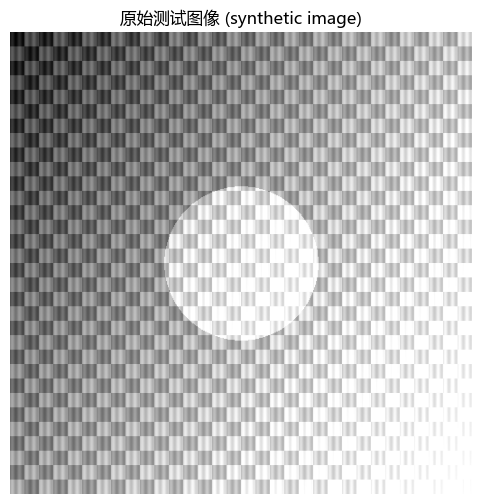

In [ ]:
def generate_synthetic_image(size=512):
    # 构建坐标网格
    y, x = np.mgrid[0:size, 0:size].astype(np.float32)

    # 归一化坐标，用于生成渐变
    gx = x / (size - 1)
    gy = y / (size - 1)

    # 组合多种结构：大尺度渐变 + 高频条纹 + 棋盘纹理 + 圆形区域
    gradient = 0.6 * gx + 0.4 * gy
    stripes = 0.15 * (np.sin(2 * np.pi * x / 8) + 1) / 2
    checker = (((x // 16 + y // 16) % 2) * 0.2).astype(np.float32)
    center = ((x - size / 2) ** 2 + (y - size / 2) ** 2) < (size / 6) ** 2
    circle = center.astype(np.float32) * 0.25

    # 融合并裁剪到 [0, 1]
    image_float = gradient + stripes + checker + circle
    image_float = np.clip(image_float, 0, 1)

    # 转为 8-bit 灰度图
    return (image_float * 255).astype(np.uint8)

# 优先使用经典测试图；若不可用则自动回退到合成图
try:
    from skimage import data
    image = data.camera()
    image_source = 'skimage.data.camera()'
except Exception:
    image = generate_synthetic_image()
    image_source = 'synthetic image'

print(f'使用图像来源: {image_source}, 尺寸: {image.shape}, 数据类型: {image.dtype}')

# 显示原始测试图像
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title(f'原始测试图像 ({image_source})')
plt.axis('off')
plt.show()

### 3.3 实现降采样与插值重建函数
这里实现最近邻与双线性插值，方便对比重建效果差异。

In [ ]:
def resize_nearest(image_array, new_height, new_width):
    """最近邻插值：把目标坐标四舍五入到最近源像素。"""
    old_height, old_width = image_array.shape

    # 在原图坐标范围内均匀取样
    y_indices = np.linspace(0, old_height - 1, new_height)
    x_indices = np.linspace(0, old_width - 1, new_width)

    # 四舍五入到最近整数索引
    y_indices = np.rint(y_indices).astype(int)
    x_indices = np.rint(x_indices).astype(int)

    return image_array[np.ix_(y_indices, x_indices)]


def resize_bilinear(image_array, new_height, new_width):
    """双线性插值：用目标点周围 4 个像素按距离加权。"""
    old_height, old_width = image_array.shape

    # 目标图像每个点映射到原图的浮点坐标
    y = np.linspace(0, old_height - 1, new_height)
    x = np.linspace(0, old_width - 1, new_width)

    # 左上角整数坐标
    y0 = np.floor(y).astype(int)
    x0 = np.floor(x).astype(int)

    # 右下角整数坐标（需要边界裁剪）
    y1 = np.clip(y0 + 1, 0, old_height - 1)
    x1 = np.clip(x0 + 1, 0, old_width - 1)

    # 与左上角的距离（作为权重基础）
    wy = y - y0
    wx = x - x0

    # 取四邻域像素值
    top_left = image_array[np.ix_(y0, x0)].astype(np.float32)
    top_right = image_array[np.ix_(y0, x1)].astype(np.float32)
    bottom_left = image_array[np.ix_(y1, x0)].astype(np.float32)
    bottom_right = image_array[np.ix_(y1, x1)].astype(np.float32)

    # 四个方向权重
    w_tl = np.outer(1 - wy, 1 - wx)
    w_tr = np.outer(1 - wy, wx)
    w_bl = np.outer(wy, 1 - wx)
    w_br = np.outer(wy, wx)

    # 加权融合并裁剪到灰度有效范围
    result = top_left * w_tl + top_right * w_tr + bottom_left * w_bl + bottom_right * w_br
    return np.clip(result, 0, 255).astype(np.uint8)


def downsample_and_reconstruct(image_array, factor, method='nearest'):
    """先降采样，再重建回原尺寸，用于观察分辨率退化效应。"""
    old_height, old_width = image_array.shape

    # 降采样后的尺寸，至少保持 2x2
    low_height = max(2, old_height // factor)
    low_width = max(2, old_width // factor)

    if method == 'nearest':
        low_image = resize_nearest(image_array, low_height, low_width)
        reconstructed = resize_nearest(low_image, old_height, old_width)
    elif method == 'bilinear':
        low_image = resize_bilinear(image_array, low_height, low_width)
        reconstructed = resize_bilinear(low_image, old_height, old_width)
    else:
        raise ValueError('method 只能是 nearest 或 bilinear')

    return low_image, reconstructed

### 3.4 实验1：不同降采样比例下的重建效果
对同一图像做 x1、x2、x4、x8、x16 降采样后再重建回原尺寸，对比两种插值方法下的马赛克和锯齿情况。

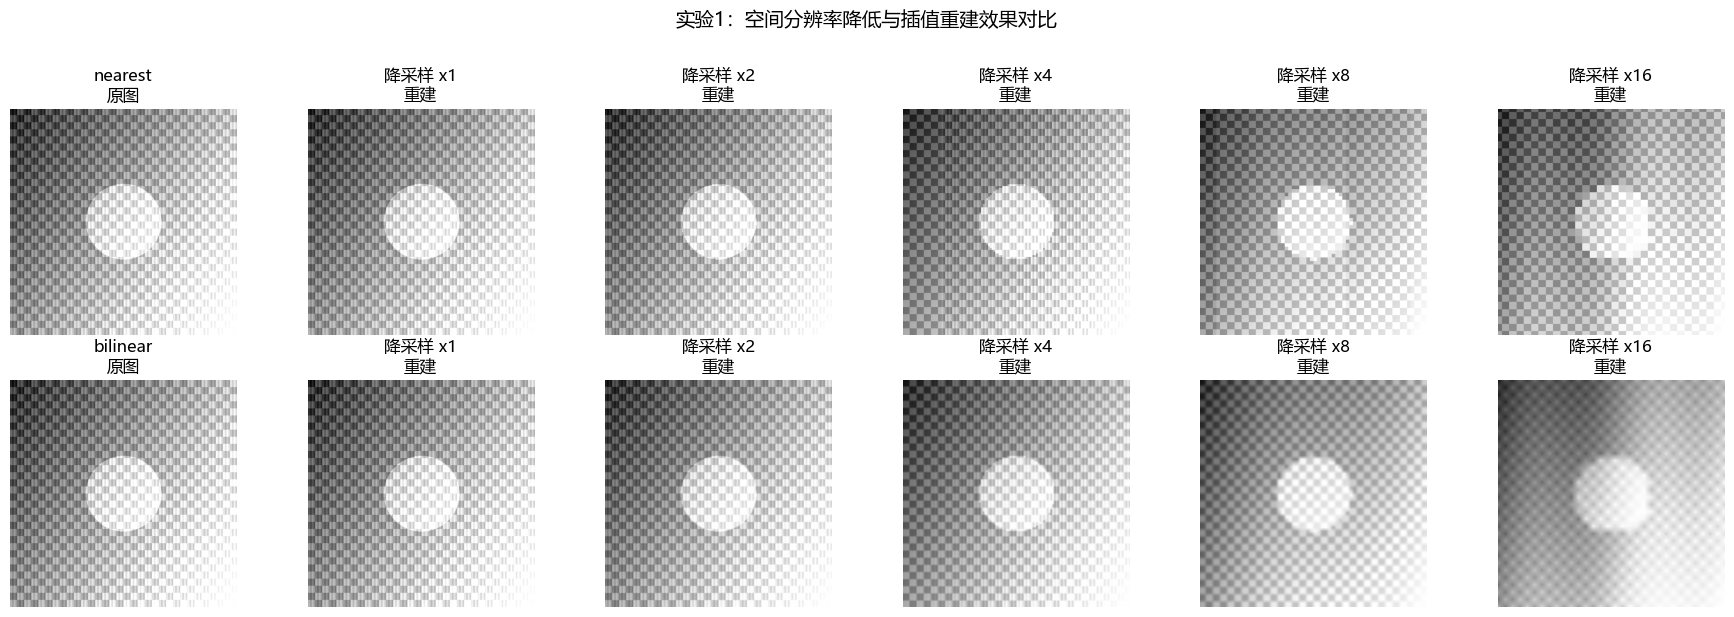

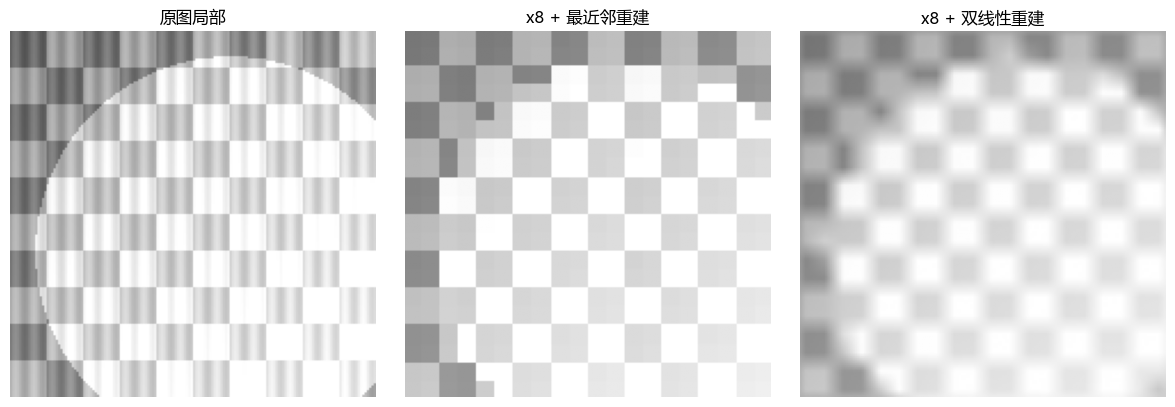

In [ ]:
# 不同降采样倍数（factor 越大，分辨率越低）
factors = [1, 2, 4, 8, 16]

# 两种重建方法：最近邻、双线性
methods = ['nearest', 'bilinear']

# 行表示方法，列表示不同 factor（第一列放原图）
figure, axes = plt.subplots(
    len(methods),
    len(factors) + 1,
    figsize=(3 * (len(factors) + 1), 3 * len(methods))
)

for row_index, method in enumerate(methods):
    # 每一行第一个子图显示原图
    axes[row_index, 0].imshow(image, vmin=0, vmax=255)
    axes[row_index, 0].set_title(f'{method}\n原图')
    axes[row_index, 0].axis('off')

    # 逐个 factor 做“降采样 + 重建”
    for column_index, factor in enumerate(factors, start=1):
        _, reconstructed_image = downsample_and_reconstruct(image, factor, method=method)
        axes[row_index, column_index].imshow(reconstructed_image, vmin=0, vmax=255)
        axes[row_index, column_index].set_title(f'降采样 x{factor}\n重建')
        axes[row_index, column_index].axis('off')

figure.suptitle('实验1：空间分辨率降低与插值重建效果对比', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 再做一个局部放大对比，更容易看出马赛克与锯齿
y_start, y_end = 160, 320
x_start, x_end = 160, 320
_, nearest_x8 = downsample_and_reconstruct(image, 8, method='nearest')
_, bilinear_x8 = downsample_and_reconstruct(image, 8, method='bilinear')

crop_original = image[y_start:y_end, x_start:x_end]
crop_nearest = nearest_x8[y_start:y_end, x_start:x_end]
crop_bilinear = bilinear_x8[y_start:y_end, x_start:x_end]

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(crop_original, vmin=0, vmax=255)
axes[0].set_title('原图局部')
axes[0].axis('off')

axes[1].imshow(crop_nearest, vmin=0, vmax=255)
axes[1].set_title('x8 + 最近邻重建')
axes[1].axis('off')

axes[2].imshow(crop_bilinear, vmin=0, vmax=255)
axes[2].set_title('x8 + 双线性重建')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 3.5 实现灰度量化函数
把图像从连续灰度映射到 $2^b$ 个离散灰度级，准备做 8-bit 到 1-bit 的对比实验。

In [ ]:
def quantize_gray(image_array, bits):
    """把 8-bit 灰度图量化为 bits 位（共 2^bits 个灰度级）。"""
    levels = 2 ** bits

    # 先归一化到 [0, 1]
    normalized = image_array.astype(np.float32) / 255.0

    # 量化到离散等级，再映射回 [0, 1]
    quantized = np.round(normalized * (levels - 1)) / (levels - 1)

    # 还原到 [0, 255] 的 uint8 图像
    return np.clip(quantized * 255, 0, 255).astype(np.uint8)

### 3.6 实验2：灰度量化等级下降与伪轮廓观察
本单元会：
1. 展示 8、6、4、3、2、1 bit 图像；
2. 计算 MSE 与 PSNR；
3. 对同一行像素画灰度曲线，观察“连续变阶梯”。

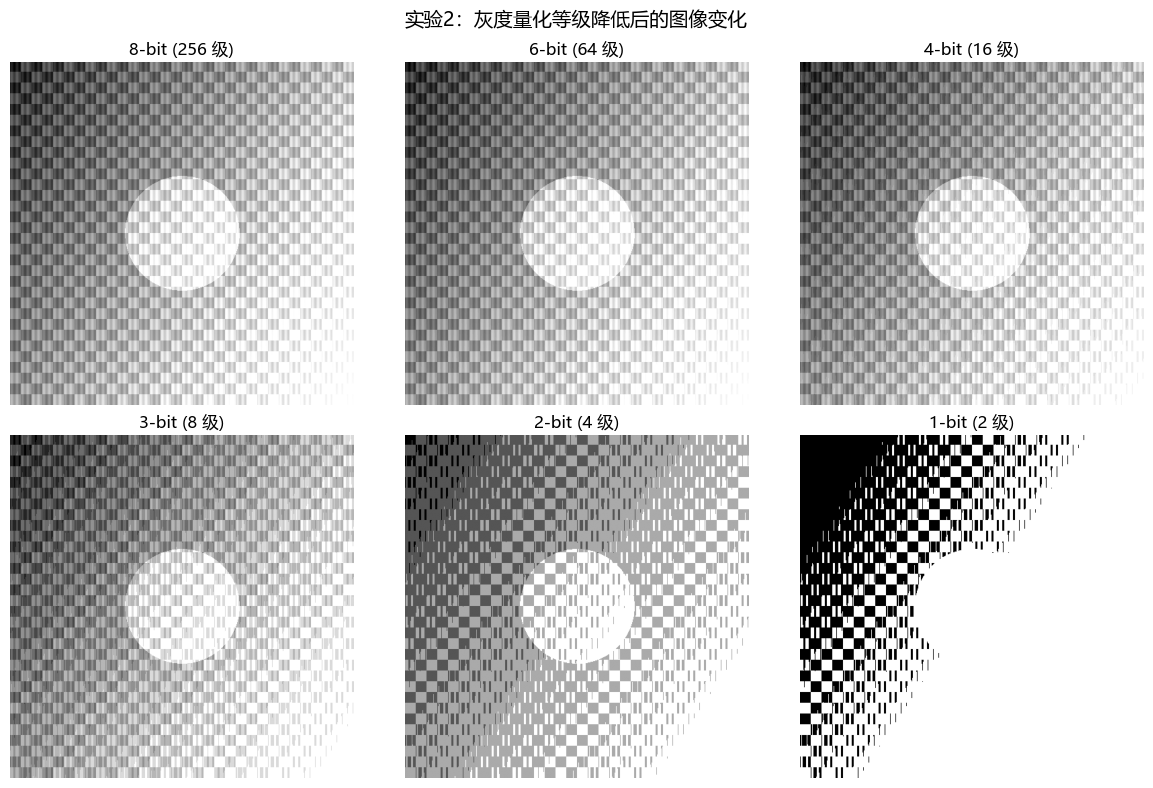

    位深       灰度级数          MSE     PSNR(dB)
     8        256       0.0000          inf
     6         64       1.3565      46.8068
     4         16      21.2369      34.8599
     3          8      98.7914      28.1836
     2          4     539.5333      20.8106
     1          2    5704.3882      10.5687


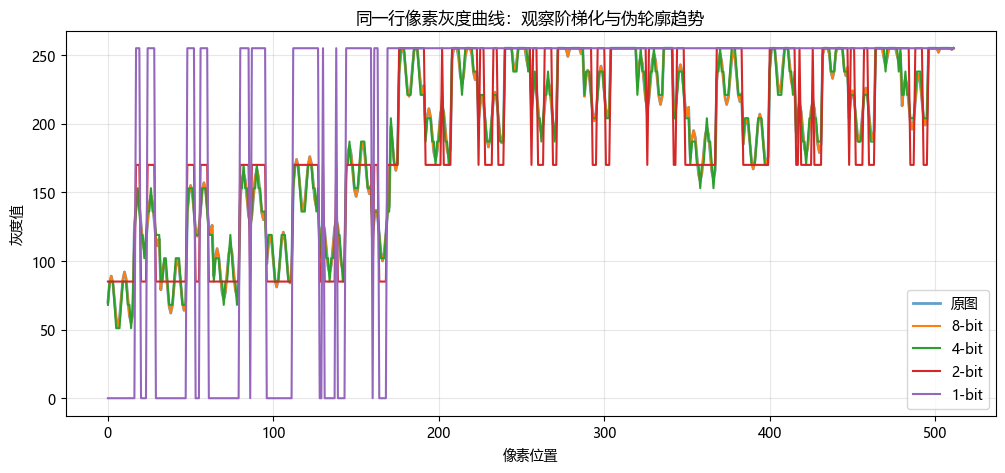

In [ ]:
# 依次降低位深，观察伪轮廓从轻到重的变化
bits_list = [8, 6, 4, 3, 2, 1]
figure, axes = plt.subplots(2, 3, figsize=(12, 8))

for axis, bits in zip(axes.flat, bits_list):
    quantized_image = quantize_gray(image, bits)
    axis.imshow(quantized_image, vmin=0, vmax=255)
    axis.set_title(f'{bits}-bit ({2 ** bits} 级)')
    axis.axis('off')

figure.suptitle('实验2：灰度量化等级降低后的图像变化', fontsize=14)
plt.tight_layout()
plt.show()


def mse(image_a, image_b):
    """均方误差：越小表示像素差异越小。"""
    difference = image_a.astype(np.float32) - image_b.astype(np.float32)
    return np.mean(difference ** 2)


def psnr(image_a, image_b):
    """峰值信噪比：越大通常表示重建质量越好。"""
    current_mse = mse(image_a, image_b)
    if current_mse == 0:
        return np.inf
    return 10 * np.log10((255 ** 2) / current_mse)


# 输出不同位深下的客观指标
print(f'{"位深":>6} {"灰度级数":>10} {"MSE":>12} {"PSNR(dB)":>12}')
for bits in bits_list:
    quantized_image = quantize_gray(image, bits)
    current_mse = mse(image, quantized_image)
    current_psnr = psnr(image, quantized_image)
    current_psnr_text = 'inf' if np.isinf(current_psnr) else f'{current_psnr:.4f}'
    print(f'{bits:>6} {2 ** bits:>10} {current_mse:>12.4f} {current_psnr_text:>12}')


# 取中间一行做灰度曲线，观察“连续 -> 阶梯”的变化
row_index = image.shape[0] // 2
profile_bits = [8, 4, 2, 1]

plt.figure(figsize=(12, 5))
plt.plot(image[row_index, :], label='原图', linewidth=2, alpha=0.7)
for bits in profile_bits:
    profile_image = quantize_gray(image, bits)
    plt.plot(profile_image[row_index, :], label=f'{bits}-bit')

plt.title('同一行像素灰度曲线：观察阶梯化与伪轮廓趋势')
plt.xlabel('像素位置')
plt.ylabel('灰度值')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.7 实验3：误差扩散改善伪轮廓
本单元实现 Floyd-Steinberg 误差扩散，并与 1-bit 直接阈值量化对比。

重点观察：
- 直接量化会产生大块黑白分区；
- 误差扩散会引入颗粒感，但视觉层次通常更自然。

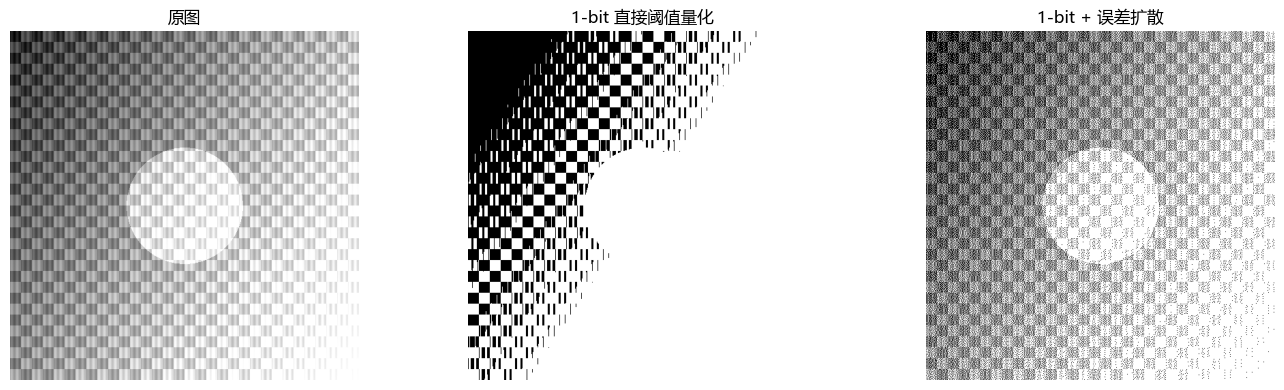

像素级 MSE（1-bit 直接量化）: 5704.3882
像素级 MSE（1-bit 误差扩散）: 10396.8447
块平均 MSE（1-bit 直接量化）: 4699.4497
块平均 MSE（1-bit 误差扩散）: 92.5291


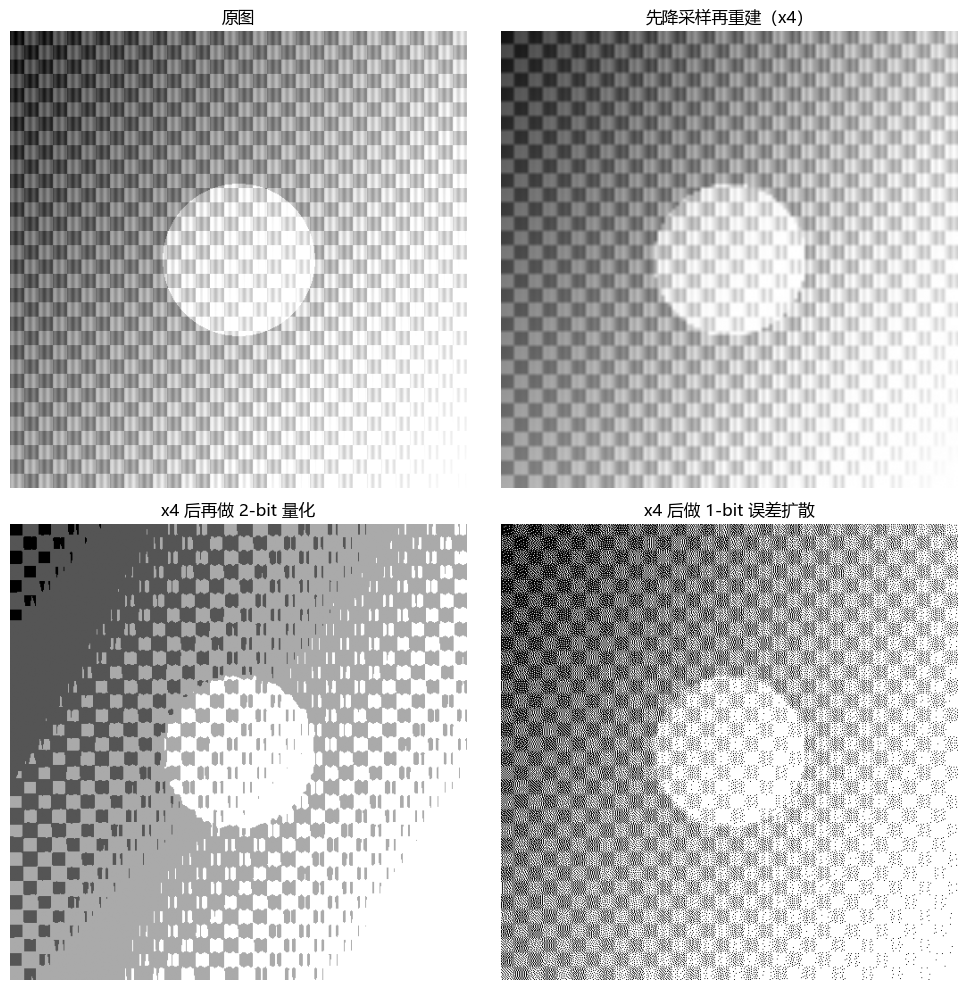

In [ ]:
def floyd_steinberg_dither(image_array):
    """Floyd-Steinberg 误差扩散，把 1-bit 量化误差扩散到邻域。"""
    work = image_array.astype(np.float32) / 255.0
    height, width = work.shape
    output = np.zeros_like(work)

    for y in range(height):
        for x in range(width):
            # 当前像素二值化（阈值 0.5）
            old_value = work[y, x]
            new_value = 1.0 if old_value >= 0.5 else 0.0
            output[y, x] = new_value

            # 计算量化误差并向邻域扩散
            error = old_value - new_value

            if x + 1 < width:
                work[y, x + 1] += error * 7 / 16
            if y + 1 < height and x - 1 >= 0:
                work[y + 1, x - 1] += error * 3 / 16
            if y + 1 < height:
                work[y + 1, x] += error * 5 / 16
            if y + 1 < height and x + 1 < width:
                work[y + 1, x + 1] += error * 1 / 16

    output = np.clip(output, 0, 1)
    return (output * 255).astype(np.uint8)


# 对比：1-bit 直接量化 vs 1-bit 误差扩散
image_threshold_1bit = quantize_gray(image, 1)
image_dither_1bit = floyd_steinberg_dither(image)

figure, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(image, vmin=0, vmax=255)
axes[0].set_title('原图')
axes[0].axis('off')

axes[1].imshow(image_threshold_1bit, vmin=0, vmax=255)
axes[1].set_title('1-bit 直接阈值量化')
axes[1].axis('off')

axes[2].imshow(image_dither_1bit, vmin=0, vmax=255)
axes[2].set_title('1-bit + 误差扩散')
axes[2].axis('off')

plt.tight_layout()
plt.show()


def block_average(image_array, block_size=4):
    """块平均：近似模拟局部视觉感知，用于辅助评价。"""
    height, width = image_array.shape
    valid_height = (height // block_size) * block_size
    valid_width = (width // block_size) * block_size

    trimmed = image_array[:valid_height, :valid_width].astype(np.float32)
    reshaped = trimmed.reshape(
        valid_height // block_size,
        block_size,
        valid_width // block_size,
        block_size
    )
    return reshaped.mean(axis=(1, 3))


# 像素级误差 vs 块平均误差
pixel_mse_threshold = mse(image, image_threshold_1bit)
pixel_mse_dither = mse(image, image_dither_1bit)
perceptual_mse_threshold = mse(block_average(image), block_average(image_threshold_1bit))
perceptual_mse_dither = mse(block_average(image), block_average(image_dither_1bit))

print(f'像素级 MSE（1-bit 直接量化）: {pixel_mse_threshold:.4f}')
print(f'像素级 MSE（1-bit 误差扩散）: {pixel_mse_dither:.4f}')
print(f'块平均 MSE（1-bit 直接量化）: {perceptual_mse_threshold:.4f}')
print(f'块平均 MSE（1-bit 误差扩散）: {perceptual_mse_dither:.4f}')


# 组合退化实验：先降空间分辨率，再降低灰度分辨率
_, low_spatial_image = downsample_and_reconstruct(image, 4, method='bilinear')
low_spatial_quantized_2bit = quantize_gray(low_spatial_image, 2)
low_spatial_dithered = floyd_steinberg_dither(low_spatial_image)

figure, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(image, vmin=0, vmax=255)
axes[0, 0].set_title('原图')
axes[0, 0].axis('off')

axes[0, 1].imshow(low_spatial_image, vmin=0, vmax=255)
axes[0, 1].set_title('先降采样再重建（x4）')
axes[0, 1].axis('off')

axes[1, 0].imshow(low_spatial_quantized_2bit, vmin=0, vmax=255)
axes[1, 0].set_title('x4 后再做 2-bit 量化')
axes[1, 0].axis('off')

axes[1, 1].imshow(low_spatial_dithered, vmin=0, vmax=255)
axes[1, 1].set_title('x4 后做 1-bit 误差扩散')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 四、总结与思考

### 实验结论
1. 空间分辨率下降会优先破坏高频细节，降采样倍数越大，马赛克与锯齿越明显。
2. 灰度量化等级下降会引发伪轮廓，尤其在平滑渐变区域。
3. 误差扩散可以显著改善低位深图像的视觉层次感，尽管像素级误差不一定最小。
4. 图像质量由“空间分辨率 + 灰度分辨率”共同决定，二者需要联合设计。

### 思考题
1. 为什么误差扩散在视觉上更自然，但像素级 MSE 可能不占优？
2. 如果应用目标是机器识别而不是人眼观察，评价指标应如何调整？
3. 能否对比更多抖动算法（如 Jarvis、Stucki）并分析差异？
4. 当图像含噪声时，降采样与量化对噪声感知会有什么影响？